In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [1]:
import jax
print(jax.devices())
print("default backend:", jax.default_backend())


[CudaDevice(id=0)]
default backend: gpu


In [3]:
from alphagenome.data import genome
from alphagenome.visualization import plot_components
from alphagenome_research.model import dna_model
from alphagenome.models import variant_scorers
from alphagenome.models import dna_client

import matplotlib.pyplot as plt
import functools
import os
from typing import Callable

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn import metrics
from sklearn.metrics import average_precision_score, roc_auc_score


I0000 00:00:1777468967.529041 4061940 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777468970.718578 4061940 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ'] 

In [4]:
# Flags to improve determinism.
os.environ['XLA_FLAGS'] = ' '.join([
    '--xla_gpu_deterministic_ops',
    '--xla_gpu_enable_scatter_determinism_expander=True',
    '--xla_gpu_enable_triton_gemm=False',
])
# Increase GPU and CPU memory to reduce out of memory errors.
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'

In [5]:
model = dna_model.create_from_huggingface('all_folds')

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/pyfaidx/__init__.py:596: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/opt/modules/i12g/anaconda/envs/IDPproject_indel_26/lib/python3.11/site-packages/pyfaidx/__init__.py:596: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


In [5]:
# @title Helper functions.

def calculate_tissue_weighted_metric(
    predictions_df: pd.DataFrame,
    metric_fn: Callable[[np.ndarray, np.ndarray], float],
    prediction_col: str = 'prediction',
    target_col: str = 'target',
    tissue_col: str = 'tissue'
) -> float:
    """
    Calculates a tissue-weighted mean for a given metric function from a DataFrame.

    Args:
        predictions_df: DataFrame containing predictions, targets, and tissue info.
        metric_fn: A function that accepts two np.ndarrays (y_true, y_pred)
                   and returns a single float metric.
                   Note: For scipy functions that return tuples (e.g., spearmanr),
                   you must wrap them in a lambda function (see example).
        prediction_col: Name of the column with prediction scores.
        target_col: Name of the column with target labels/values.
        tissue_col: Name of the column indicating the tissue/group.

    Returns:
        The calculated tissue-weighted mean metric, or np.nan if unable to calculate.
    """
    if predictions_df is None or predictions_df.empty:
        print("Warning: predictions_df is empty, returning NaN.")
        return float('nan')

    required_cols = [prediction_col, target_col, tissue_col]
    if not all(col in predictions_df.columns for col in required_cols):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")

    tissue_results = []

    # Group by tissue and calculate the metric for each one.
    for tissue_name, group_df in predictions_df.groupby(tissue_col):

        # Drop rows where target or prediction is NaN.
        clean_group = group_df.dropna(subset=[target_col, prediction_col])

        num_variants = len(clean_group)

        # Skip tissues with < 2 variants (can't calculate metrics).
        if num_variants < 2:
            # print(f"Skipping tissue {tissue_name} (variants={num_variants})")
            continue

        try:
            # Calculate the metric for this one tissue using the passed function
            metric_value = metric_fn(
                clean_group[target_col], clean_group[prediction_col]
            )

            # Ensure metric is a valid number.
            if not np.isfinite(metric_value):
                print(f"Skipping tissue {tissue_name} (metric_fn returned non-finite value)")
                continue

            tissue_results.append({
                'tissue': tissue_name,
                'metric_value': metric_value,
                'count': num_variants  # This is the "weight".
            })
        except ValueError as e:
            # This will catch single-class errors for AUROC/AUPRC
            # and other potential issues from metric_fn.
            print(f"Could not calculate metric for tissue {tissue_name}: {e}")
            continue # Skip tissue if metric calculation fails.

    if not tissue_results:
        print("Warning: No tissues had scorable metric values, returning NaN.")
        return float('nan')

    # Create a DataFrame of the per-tissue metrics.
    metrics_df = pd.DataFrame(tissue_results)

    # Calculate the final weighted mean.
    weighted_sum = (metrics_df['metric_value'] * metrics_df['count']).sum()
    total_count = metrics_df['count'].sum()

    if total_count == 0:
         print("Warning: Total count for weighting is zero, returning NaN.")
         return float('nan')

    weighted_mean_metric = weighted_sum / total_count
    return weighted_mean_metric


def paqtl_auprc(df):
  SEED = 0

  # 1. Separate positives and negatives.
  pos = df[df['target'] == 1]
  neg = df[df['target'] == 0]

  # 2. Merge on 'PI' to find all valid matched pairs.
  matched = pd.merge(
      pos,
      neg,
      on='PI',
      how='inner',
      suffixes=('_pos', '_neg')
  )

  # 3. Group by 'PI' and sample exactly one pair per group.
  # This ensures 1:1 matching controlled by PI.
  sampled_pairs = matched.groupby('PI').sample(n=1, random_state=SEED)

  # 4. Reconstruct a single dataframe for AUPRC calculation
  # We stack the positive and negative parts of the sampled pairs back together.
  df_sampled = pd.concat([
      sampled_pairs[['prediction_pos', 'target_pos']].rename(
          columns={'prediction_pos': 'prediction', 'target_pos': 'target'}
      ),
      sampled_pairs[['prediction_neg', 'target_neg']].rename(
          columns={'prediction_neg': 'prediction', 'target_neg': 'target'}
      )
  ])
  return metrics.average_precision_score(
      df_sampled['target'], df_sampled['prediction'])

auroc_fn = roc_auc_score
auprc_fn = average_precision_score

spearman_fn = lambda y_true, y_pred: spearmanr(y_true, y_pred)[0]


In [6]:


urls = ["https://storage.googleapis.com/alphagenome/evals/eqtl_variant_borzoi_coefficient_human_predictions.feather",
        "https://storage.googleapis.com/alphagenome/evals/eqtl_variant_catalogue_causality_gene_balanced_human_predictions.feather"]

dfs = [pd.read_feather(url) for url in urls]

df_coefficient = dfs[0]
df_zeroshot = dfs[1]
df_coefficient = df_coefficient.dropna(subset=['target'])
df_zeroshot = df_zeroshot.dropna(subset=['target'])

In [7]:
def score_variant(variant_id: str) -> pd.DataFrame: 

    parts = variant_id.split("_")

    if len(parts) == 5:
        chrom, pos, ref, alt, ext = parts
    elif len(parts) == 4:
        chrom, pos, ref, alt = parts
        ext = None
    else:
        raise ValueError(f"Unexpected variant_id format: {variant_id}")

    # build variant object
    variant = genome.Variant(
        chromosome=chrom,
        position=int(pos),
        reference_bases=ref,
        alternate_bases=alt,
    )

        
    # Create a 1MB interval centered on the variant.
    interval = variant.reference_interval.resize(2**20)

    variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ'] 
    variant_scores = model.score_variant(
        interval=interval, 
        variant=variant, 
        variant_scorers=[variant_scorer],
        organism=dna_client.Organism.HOMO_SAPIENS,
    )
    variant_scores = variant_scorers.tidy_scores(variant_scores)
    
    return variant_scores

In [ ]:

unique_variants = df_coefficient["variant_id"].unique()

# run half of the variants
#unique_variants = unique_variants[len(unique_variants) // 2 + 1:len(unique_variants)]
variant_scores_dic = {}


from tqdm import tqdm
for variant in tqdm(unique_variants):
    variant_scores_dic[variant] = score_variant(variant)



In [ ]:
df_coefficient_results = []

for row_nr in range(len(df_coefficient)):
    row = df_coefficient.iloc[row_nr]
    variant = row.variant_id
    
    if variant not in variant_scores_dic:
        continue
    
    variant_scores = variant_scores_dic[variant]
    
    mask = (
        (variant_scores["gene_id"] == row.gene_id.split('.')[0]) &
        (variant_scores["gtex_tissue"] == row.tissue)
    )

    filtered = variant_scores.loc[mask, "raw_score"]

    new_prediction = filtered.iloc[0] if not filtered.empty else np.nan
    # add prediction from model to the row and then collect row in a new dataframe for all variants
    new_row = row.copy()
    new_row['prediction_new'] = new_prediction

    df_coefficient_results.append(new_row)


In [ ]:
# output dataframe to file
import pandas as pd

df_results = pd.DataFrame(df_coefficient_results)
df_results.to_feather("results/local/local_coefficients.feather")

In [8]:
# @title Eval configs.
PREDS_PATH = 'https://storage.googleapis.com/alphagenome/evals'

evals = {
    'eqtl_variant_catalogue_causality_gene_balanced_human': {
        'output_type':      'RNA_SEQ',
        'metric_name':      'tissue_weighted_mean_auroc',
        'metric_fn':        functools.partial(calculate_tissue_weighted_metric, metric_fn=auroc_fn),
        'reported_metric':  0.713255,
    },
    'eqtl_variant_borzoi_coefficient_human': {
        'output_type':      'RNA_SEQ',
        'metric_name':      'tissue_weighted_mean_spearmanr',
        'metric_fn':        functools.partial(calculate_tissue_weighted_metric, metric_fn=spearman_fn, prediction_col='output_type'),
        'reported_metric':  0.500588,
    }
}

In [9]:
eval_name = 'eqtl_variant_borzoi_coefficient_human'
print(f"\nEval: {eval_name}")
predictions = pd.read_feather("results/local/local_coefficients.feather")

c = evals[eval_name]
recomputed_metric = calculate_tissue_weighted_metric(predictions, metric_fn=spearman_fn, prediction_col='prediction_new')

print(f"  Reported:   {c['reported_metric']}")
print(f"  Recomputed: {recomputed_metric:.4f}")

if c.get('notes'):
    print(f"  Notes:      {c['notes']}")


Eval: eqtl_variant_borzoi_coefficient_human
  Reported:   0.500588
  Recomputed: 0.4988


Spearman: 0.8560
Pearson:  0.9940


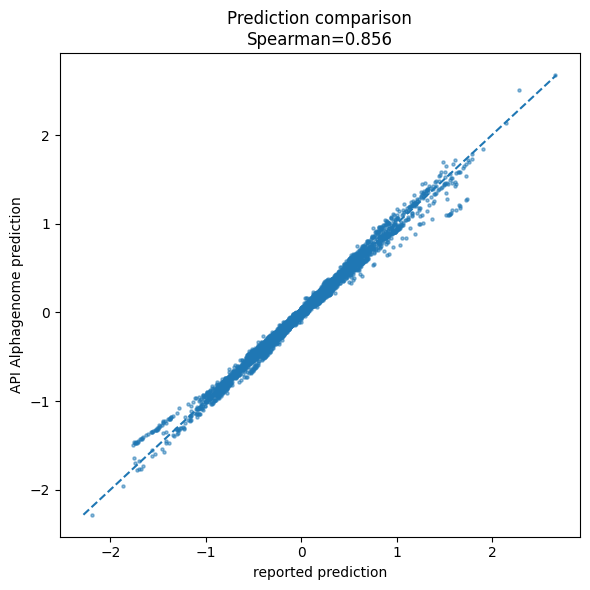

In [10]:

# to function
def compare_predictions(df, col_name1, col_name2):
    df_clean = df[[col_name1, col_name2]].dropna()

    # --- extract arrays ---
    y1 = df_clean[col_name1].values
    y2 = df_clean[col_name2].values

    # --- metrics ---
    spearman = spearmanr(y1, y2)[0]
    pearson = pearsonr(y1, y2)[0]

    print(f"Spearman: {spearman:.4f}")
    print(f"Pearson:  {pearson:.4f}")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 6))
    plt.scatter(y1, y2, s=5, alpha=0.5)
    # diagonal line (perfect agreement)
    min_val = min(y1.min(), y2.min())
    max_val = max(y1.max(), y2.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("reported prediction")
    plt.ylabel("API Alphagenome prediction")
    plt.title(f"Prediction comparison\nSpearman={spearman:.3f}")
    plt.tight_layout()
    plt.show()


compare_predictions(predictions, "prediction", "prediction_new")

In [15]:
predictions = pd.read_feather("results/local/local_coefficients.feather")
predictions.head()

,variant_id,gene_id,tissue,prediction,target,variant_scorer,output_type,metric_calculator,metric_name,prediction_new
0,chr3_4491276_T_C_b38,ENSG00000231249.3,Adipose_Subcutaneous,0.101731,0.279811,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.098881
1,chr3_8733693_G_T_b38,ENSG00000182533.7,Adipose_Subcutaneous,0.014747,0.567912,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.000123
2,chr3_8963418_C_T_b38,ENSG00000070950.10,Adipose_Subcutaneous,-0.095976,-0.684296,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.092913
3,chr3_9867065_G_C_b38,ENSG00000187288.12,Adipose_Subcutaneous,-0.000609,-0.130677,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.002774
4,chr3_9903375_C_T_b38,ENSG00000163701.19,Adipose_Subcutaneous,-0.035684,-0.660048,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.022656


## My prediction vs reported
Eval: eqtl_variant_borzoi_coefficient_human
  Reported:   0.500588
  Recomputed: 0.4988

## Zero shot

In [10]:


unique_variants = df_zeroshot["variant_id"].unique()

# run half of the variants
unique_variants = unique_variants[len(unique_variants) // 2 + 1:len(unique_variants)]
# unique_variants = unique_variants[:10]

variant_scores_dic = {}


from tqdm import tqdm
for variant in tqdm(unique_variants):
    #print("Scoring variant:", variant, flush=True)
    variant_scores_dic[variant] = score_variant(variant)



100%|██████████| 6265/6265 [6:03:19<00:00,  3.48s/it]  


In [11]:
df_zeroshot_results = []

for row_nr in range(len(df_zeroshot)):
    row = df_zeroshot.iloc[row_nr]
    variant = row.variant_id
    
    if variant not in variant_scores_dic:
        continue
    
    variant_scores = variant_scores_dic[variant]
    
    mask = (
        (variant_scores["gene_id"] == row.gene_id.split('.')[0]) &
        (variant_scores["gtex_tissue"] == row.tissue)
    )

    filtered = variant_scores.loc[mask, "raw_score"]

    new_prediction = filtered.iloc[0] if not filtered.empty else np.nan
    # add prediction from model to the row and then collect row in a new dataframe for all variants
    new_row = row.copy()
    new_row['prediction_new'] = new_prediction

    df_zeroshot_results.append(new_row)


In [12]:
# output dataframe to file
import pandas as pd

df_results = pd.DataFrame(df_zeroshot_results)
df_results.to_feather("results/local/local_zeroshot_part2.feather")

In [13]:
# @title Eval configs.
PREDS_PATH = 'https://storage.googleapis.com/alphagenome/evals'

evals = {
    'eqtl_variant_catalogue_causality_gene_balanced_human': {
        'output_type':      'RNA_SEQ',
        'metric_name':      'tissue_weighted_mean_auroc',
        'metric_fn':        functools.partial(calculate_tissue_weighted_metric, metric_fn=auroc_fn),
        'reported_metric':  0.713255,
    },
    'eqtl_variant_borzoi_coefficient_human': {
        'output_type':      'RNA_SEQ',
        'metric_name':      'tissue_weighted_mean_spearmanr',
        'metric_fn':        functools.partial(calculate_tissue_weighted_metric, metric_fn=spearman_fn, prediction_col='output_type'),
        'reported_metric':  0.500588,
    }
}

In [11]:
eval_name = 'eqtl_variant_catalogue_causality_gene_balanced_human'
print(f"\nEval: {eval_name}")

df1 = pd.read_feather("results/local/local_zeroshot_part1.feather")
df2 = pd.read_feather("results/local/local_zeroshot_part2.feather")

predictions = pd.concat([df1, df2], ignore_index=True)
predictions['prediction_new_abs'] = abs(predictions['prediction_new'])

c = evals[eval_name]
recomputed_metric = calculate_tissue_weighted_metric(predictions, metric_fn=auroc_fn, prediction_col='prediction_new_abs')

print(f"  Reported:   {c['reported_metric']}")
print(f"  Recomputed: {recomputed_metric:.4f}")

if c.get('notes'):
    print(f"  Notes:      {c['notes']}")


Eval: eqtl_variant_catalogue_causality_gene_balanced_human
  Reported:   0.713255
  Recomputed: 0.7178


In [9]:
predictions.head()

,variant_id,gene_id,tissue,prediction,target,variant_scorer,output_type,metric_calculator,metric_name,prediction_new,prediction_new_abs
0,chr6_35141318_A_G,ENSG00000124678,Adipose_Subcutaneous,0.015841,0.0,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataAUROC,None,0.008867,0.008867
1,chr16_84924808_A_G,ENSG00000279622,Adipose_Subcutaneous,0.237943,1.0,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataAUROC,None,0.219299,0.219299
2,chr18_46104399_G_C,ENSG00000152240,Adipose_Subcutaneous,0.249200,1.0,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataAUROC,None,0.248327,0.248327
3,chr19_49691588_C_A,ENSG00000169169,Adipose_Subcutaneous,0.177043,1.0,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataAUROC,None,0.165077,0.165077
4,chr19_53365706_G_C,ENSG00000203326,Adipose_Subcutaneous,0.030469,1.0,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataAUROC,None,-0.056275,0.056275


Spearman: 0.8390
Pearson:  0.9953


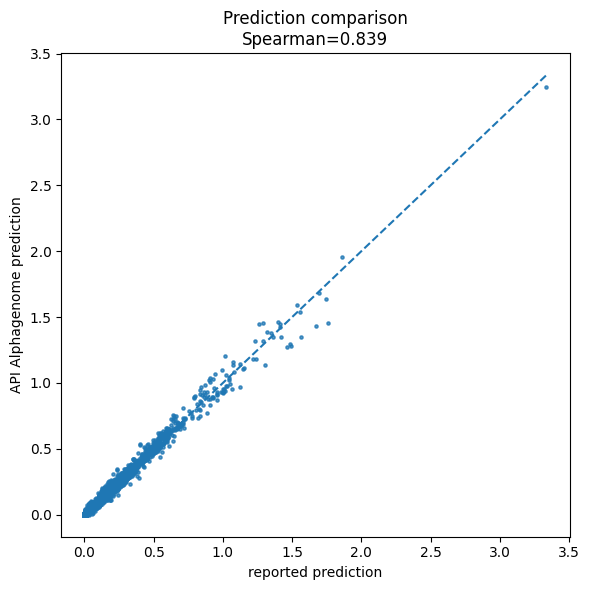

In [12]:
compare_predictions(predictions, "prediction", "prediction_new_abs")